# SIT320 Distinction Task: Tic-tac-toe with dynamic programming and Q-learning

Michael Pappas

This notebook reformulates tic-tac-toe as a Markov Decision Process, solves it with policy iteration and value iteration (Task 1), then learns the same game with tabular Q-learning against the black-box environment (Task 2) and compares the two.

The agent always plays X and moves first. The opponent O is part of the environment and picks uniformly at random among the empty cells. The three modules `TicTacToeMDP.py`, `TicTacToeDP.py` and `TicTacToeQLearner.py` follow the same method names as the `GridWorld`, `PolicyIteration`, `ValueIteration` and `QLearner` classes from the seminar framework.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from time import time

from TicTacToeMDP import TicTacToeMDP, board_to_str, LINES
from TicTacToeDP import TicTacToePolicyIteration, TicTacToeValueIteration, q_value
from TicTacToeQLearner import TicTacToeQLearner, random_opponent, minimax_opponent, evaluate

os.makedirs('figures', exist_ok=True)
np.random.seed(320)

## 1. The MDP formulation

The MDP has these parts.

States are every board that can be reached from the empty board with X to move, plus every terminal board (X won, O won, or full) that X can land on. Boards where O is to move are never states because O's reply is folded into the transition. Cells are numbered 0 to 8 row by row.

Actions are the nine cells. Only empty cells are legal in a state.

Rewards are attached to the state the agent arrives in, the same convention as `GridWorld.reward_function`: +1 for a board where X has three in a row, -1 for a board where O has, 0 for a draw and 0 for every other board.

Transition probabilities. If placing X at cell a finishes the game the next state is that terminal board with probability 1. Otherwise O picks one of the k remaining empty cells with probability 1/k each, so P(s' | s, a) = 1/k for each of those k boards. That is the uniform transition assumption from the brief.

The model is built once by breadth-first search from the empty board and stored sparsely as `transitions[s][a] = [(s', p), ...]`.

In [2]:
t0 = time()
problem = TicTacToeMDP()
print(f'built in {time() - t0:.3f} s')
for k, v in problem.summary().items():
    print(f'{k:>20}: {v}')

built in 0.048 s
              states: 3381
        non_terminal: 2423
            terminal: 958
              x_wins: 626
              o_wins: 316
               draws: 16
 nonzero_transitions: 24258


The empty board is state 0. Each of its nine actions leads to eight possible boards (X placed, then one of O's eight replies), each with probability 1/8. The reward on every one of those boards is 0 because nobody can have three in a row after two moves.

In [3]:
s0 = problem.start_state
print(f'start state index = {s0}, board = {board_to_str(problem.states[s0])}')
print(f'legal actions = {problem.legal_actions[s0]}')
for a in [0, 4]:
    print(f'--- action a = {a} (X in cell {a}) ---')
    for s_prime, p in problem.transitions[s0][a]:
        print(f"  s' = {s_prime:4d}  board = {board_to_str(problem.states[s_prime])}  p = {p:.4f}  R(s') = {problem.reward_function[s_prime]:+.0f}")

start state index = 0, board = .........
legal actions = [0, 1, 2, 3, 4, 5, 6, 7, 8]
--- action a = 0 (X in cell 0) ---
  s' =    1  board = XO.......  p = 0.1250  R(s') = +0
  s' =    2  board = X.O......  p = 0.1250  R(s') = +0
  s' =    3  board = X..O.....  p = 0.1250  R(s') = +0
  s' =    4  board = X...O....  p = 0.1250  R(s') = +0
  s' =    5  board = X....O...  p = 0.1250  R(s') = +0
  s' =    6  board = X.....O..  p = 0.1250  R(s') = +0
  s' =    7  board = X......O.  p = 0.1250  R(s') = +0
  s' =    8  board = X.......O  p = 0.1250  R(s') = +0
--- action a = 4 (X in cell 4) ---
  s' =   33  board = O...X....  p = 0.1250  R(s') = +0
  s' =   34  board = .O..X....  p = 0.1250  R(s') = +0
  s' =   35  board = ..O.X....  p = 0.1250  R(s') = +0
  s' =   36  board = ...OX....  p = 0.1250  R(s') = +0
  s' =   37  board = ....XO...  p = 0.1250  R(s') = +0
  s' =   38  board = ....X.O..  p = 0.1250  R(s') = +0
  s' =   39  board = ....X..O.  p = 0.1250  R(s') = +0
  s' =   40  board =

A state two moves from the end shows the reward structure. Here X has a winning move, and every other move hands O the chance to win or continue.

action a = 2:
  s' = 3357  XXXOO....  p = 1.000  R = +1  terminal = True
action a = 5:
  s' = 2917  XXOOOX...  p = 0.250  R = +0  terminal = False
  s' = 2898  XX.OOXO..  p = 0.250  R = +0  terminal = False
  s' = 2844  XX.OOX.O.  p = 0.250  R = +0  terminal = False
  s' = 2742  XX.OOX..O  p = 0.250  R = +0  terminal = False


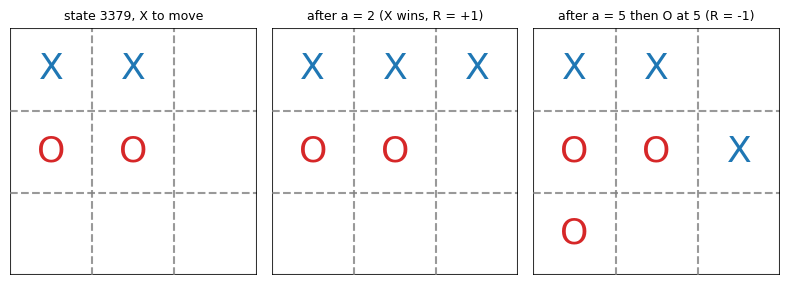

In [4]:
# X at 0 and 1, O at 3 and 4. X to move; cell 2 wins immediately.
demo = problem.state_index[(1, 1, 0, 2, 2, 0, 0, 0, 0)]
fig, axes = plt.subplots(1, 3, figsize=(8, 2.8))
problem.plot_board(demo, ax=axes[0], title=f'state {demo}, X to move')
for a in [2, 5]:
    print(f'action a = {a}:')
    for s_prime, p in problem.transitions[demo][a]:
        print(f"  s' = {s_prime}  {board_to_str(problem.states[s_prime])}  p = {p:.3f}  R = {problem.reward_function[s_prime]:+.0f}  terminal = {problem.terminal[s_prime]}")
problem.plot_board(problem.transitions[demo][2][0][0], ax=axes[1], title='after a = 2 (X wins, R = +1)')
problem.plot_board(problem.transitions[demo][5][1][0], ax=axes[2], title='after a = 5 then O at 5 (R = -1)')
plt.tight_layout()
plt.savefig('figures/mdp_example_state.png', dpi=200)
plt.show()

## 2. Uniform initial policy

The brief asks for a uniform initial policy. `generate_uniform_policy` returns a stochastic policy that gives every legal move in a state equal probability. Evaluating that policy on its own tells us how well "random X versus random O" does before any improvement. The value of the empty board under this policy is the expected reward of a random-versus-random game, discounted by gamma each agent move.

In [5]:
gamma = 0.9
uniform = problem.generate_uniform_policy()
print('uniform policy at the empty board:', np.round(uniform[s0], 3))

evaluator = TicTacToePolicyIteration(problem, gamma=gamma, init_policy=uniform.copy())
sweeps = evaluator.run_policy_evaluation(tol=1e-6)
print(f'policy evaluation converged in {sweeps} sweeps')
print(f'V_uniform(empty board) = {evaluator.values[s0]:.4f}')
print(f'win/draw/loss rate of the uniform policy vs random O (10000 games): '
      f'{np.round(evaluate(problem, problem.generate_random_policy(), random_opponent, 10000), 3)}')

uniform policy at the empty board: [0.111 0.111 0.111 0.111 0.111 0.111 0.111 0.111 0.111]


policy evaluation converged in 6 sweeps
V_uniform(empty board) = 0.2005


win/draw/loss rate of the uniform policy vs random O (10000 games): [0.56  0.095 0.345]


## 3. Policy iteration

Each epoch runs policy evaluation to a tolerance of 1e-6, then one greedy improvement sweep. The first epoch starts from the uniform stochastic policy, so the first improvement replaces it with a deterministic greedy policy and changes most states at once. After that only a handful of states change, and training stops on an epoch with zero changes.

The Bellman backup in `q_value` is Q(s, a) = sum over s' of P(s' | s, a) [R(s') + gamma V(s')], and V(terminal) = 0 because terminal states have no legal actions.

policy iteration finished in 0.16 s
epochs = 4
sweeps per policy evaluation = [6, 5, 2, 2]
policy updates per improvement = [1374, 111, 1, 0]
V*(empty board) = 0.7927, first move = cell 0


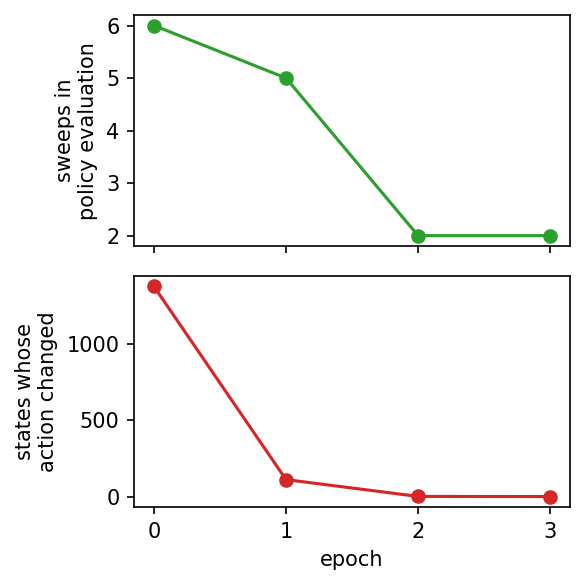

In [6]:
np.random.seed(320)
t0 = time()
pi_solver = TicTacToePolicyIteration(problem, gamma=gamma)
eval_counts, policy_changes = pi_solver.train(tol=1e-6, plot=False)
t_pi = time() - t0
print(f'policy iteration finished in {t_pi:.2f} s')
print(f'epochs = {len(policy_changes)}')
print(f'sweeps per policy evaluation = {eval_counts}')
print(f'policy updates per improvement = {policy_changes}')
print(f'V*(empty board) = {pi_solver.values[s0]:.4f}, first move = cell {pi_solver.policy[s0]}')

fig, axes = plt.subplots(2, 1, figsize=(4, 4), sharex='all', dpi=150)
axes[0].plot(eval_counts, marker='o', color='#2ca02c')
axes[0].set_ylabel('sweeps in\npolicy evaluation')
axes[1].plot(policy_changes, marker='o', color='#d62728')
axes[1].set_ylabel('states whose\naction changed')
axes[1].set_xlabel('epoch')
plt.tight_layout()
plt.savefig('figures/policy_iteration_history.png', dpi=200)
plt.show()

## 4. Value iteration

Value iteration skips the separate evaluation phase and applies the Bellman optimality backup V(s) = max over a of Q(s, a) in place, state by state. The tic-tac-toe MDP is a directed acyclic graph at most five agent moves deep, and `TicTacToeMDP` stores states in the order the depth-first build discovered them, so a single sweep already carries most terminal rewards several moves back up the tree. That is why the deltas drop to zero after four sweeps instead of decaying geometrically the way they do in GridWorld, where the agent can loop.

value iteration finished in 0.17 s
iterations = 4
delta per iteration = [1.       0.9      0.792703 0.      ]
V*(empty board) = 0.7927, first move = cell 2


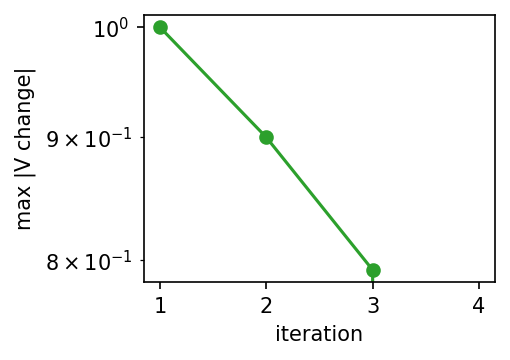

In [7]:
np.random.seed(320)
t0 = time()
vi_solver = TicTacToeValueIteration(problem, gamma=gamma)
deltas = vi_solver.train(tol=1e-6, plot=False)
t_vi = time() - t0
print(f'value iteration finished in {t_vi:.2f} s')
print(f'iterations = {len(deltas)}')
print(f'delta per iteration = {np.round(deltas, 6)}')
print(f'V*(empty board) = {vi_solver.values[s0]:.4f}, first move = cell {vi_solver.policy[s0]}')

fig, ax = plt.subplots(1, 1, figsize=(3.5, 2.5), dpi=150)
ax.semilogy(np.arange(len(deltas)) + 1, deltas, marker='o', color='#2ca02c')
ax.set_xlabel('iteration')
ax.set_ylabel('max |V change|')
plt.tight_layout()
plt.savefig('figures/value_iteration_delta.png', dpi=200)
plt.show()

## 5. Do the two DP solutions agree?

The value functions should match to within tolerance. The greedy actions can differ where two moves have exactly the same Q value (symmetric boards produce a lot of these), so the honest comparison is on values and on the Q value of each policy's chosen action, not on raw action agreement.

In [8]:
non_term = ~problem.terminal
print(f'max |V_PI - V_VI| over all states = {np.abs(pi_solver.values - vi_solver.values).max():.2e}')

same_action = (pi_solver.policy == vi_solver.policy)[non_term].mean()
q_pi = np.array([q_value(problem, vi_solver.values, s, pi_solver.policy[s], gamma) for s in np.flatnonzero(non_term)])
q_vi = np.array([q_value(problem, vi_solver.values, s, vi_solver.policy[s], gamma) for s in np.flatnonzero(non_term)])
print(f'states where PI and VI pick the same cell = {same_action:.1%}')
print(f'states where the two chosen cells have equal Q value = {np.isclose(q_pi, q_vi).mean():.1%}')

dp_policy = vi_solver.policy
dp_values = vi_solver.values

max |V_PI - V_VI| over all states = 0.00e+00
states where PI and VI pick the same cell = 84.4%
states where the two chosen cells have equal Q value = 100.0%


The optimal first move and the value of every opening cell against a random opponent:

Q*(empty board, a) for each opening cell:
cell 0: 0.7927   cell 1: 0.7864   cell 2: 0.7927
cell 3: 0.7864   cell 4: 0.7881   cell 5: 0.7864
cell 6: 0.7927   cell 7: 0.7864   cell 8: 0.7927


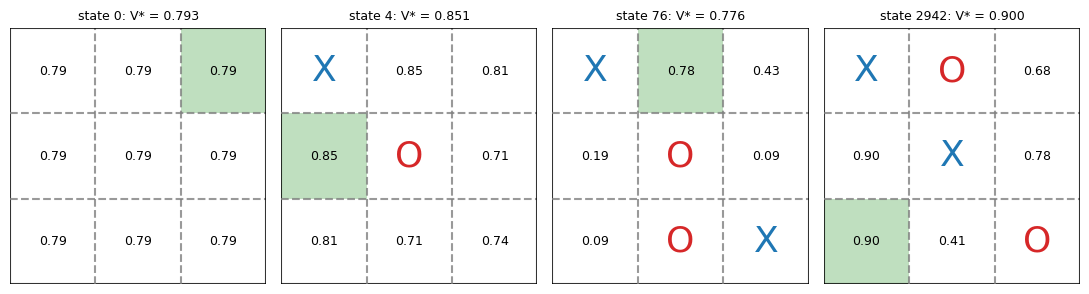

In [9]:
q_open = {a: q_value(problem, dp_values, s0, a, gamma) for a in range(9)}
print('Q*(empty board, a) for each opening cell:')
for r in range(3):
    print('   '.join(f'cell {3*r+c}: {q_open[3*r+c]:.4f}' for c in range(3)))

fig, axes = plt.subplots(1, 4, figsize=(11, 2.9))
examples = [s0,
            problem.state_index[(1, 0, 0, 0, 2, 0, 0, 0, 0)],
            problem.state_index[(1, 0, 0, 0, 2, 0, 0, 2, 1)],
            problem.state_index[(1, 2, 0, 0, 1, 0, 0, 0, 2)]]
for ax, s in zip(axes, examples):
    cell_q = np.full(9, np.nan)
    for a in problem.legal_actions[s]:
        cell_q[a] = q_value(problem, dp_values, s, a, gamma)
    problem.plot_board(s, ax=ax, values=cell_q, policy=dp_policy, title=f'state {s}: V* = {dp_values[s]:.3f}')
plt.tight_layout()
plt.savefig('figures/dp_policy_examples.png', dpi=200)
plt.show()

## 6. Playing the DP policy

Against the random opponent it was optimised for, and against a perfect minimax opponent it never saw. The second test checks whether "optimal against random" also means "safe against anyone".

In [10]:
np.random.seed(320)
dp_vs_random = evaluate(problem, dp_policy, random_opponent, n=10000)
dp_vs_minimax = evaluate(problem, dp_policy, minimax_opponent, n=1000)
print(f'DP policy vs random O   (10000 games): win {dp_vs_random[0]:.3f}  draw {dp_vs_random[1]:.3f}  loss {dp_vs_random[2]:.3f}')
print(f'DP policy vs minimax O  ( 1000 games): win {dp_vs_minimax[0]:.3f}  draw {dp_vs_minimax[1]:.3f}  loss {dp_vs_minimax[2]:.3f}')

DP policy vs random O   (10000 games): win 0.993  draw 0.007  loss 0.000
DP policy vs minimax O  ( 1000 games): win 0.000  draw 1.000  loss 0.000


## 7. Q-learning against the black box

Q-learning only sees `problem.reset()` and `problem.blackbox_move(s, a)`, which samples one successor from the same transition model the DP solver read directly. The solver below mirrors `GridWorldQSolver` from the seminar notebook. One episode is one full game; epsilon decays by `xi` after each game.

In [11]:
class TicTacToeQSolver:
    def __init__(self, problem, alpha=0.2, gamma=0.9, epsilon=1.0, xi=0.999, epsilon_min=0.0):
        self.problem = problem
        self.learner = TicTacToeQLearner(problem.num_states, problem.num_actions, problem.legal_actions,
                                         alpha=alpha, gamma=gamma, epsilon=epsilon, xi=xi, epsilon_min=epsilon_min)

    def train_one_episode(self):
        s = self.problem.reset()
        while True:
            a = self.learner.actuate(s)
            s_prime, r = self.problem.blackbox_move(s, a)
            self.learner.percept(s, a, s_prime, r)
            if self.problem.terminal[s_prime]:
                break
            s = s_prime
        self.learner.update_episode()
        return r  # +1 win, 0 draw, -1 loss

    def train(self, episodes):
        outcomes = np.zeros(episodes)
        for i in range(episodes):
            outcomes[i] = self.train_one_episode()
        return outcomes


def rolling_rates(outcomes, window=500):
    kernel = np.ones(window) / window
    win = np.convolve(outcomes == 1, kernel, mode='valid')
    draw = np.convolve(outcomes == 0, kernel, mode='valid')
    loss = np.convolve(outcomes == -1, kernel, mode='valid')
    x = np.arange(window, len(outcomes) + 1)
    return x, win, draw, loss

40000 episodes in 2.5 s, final epsilon = 0.0003


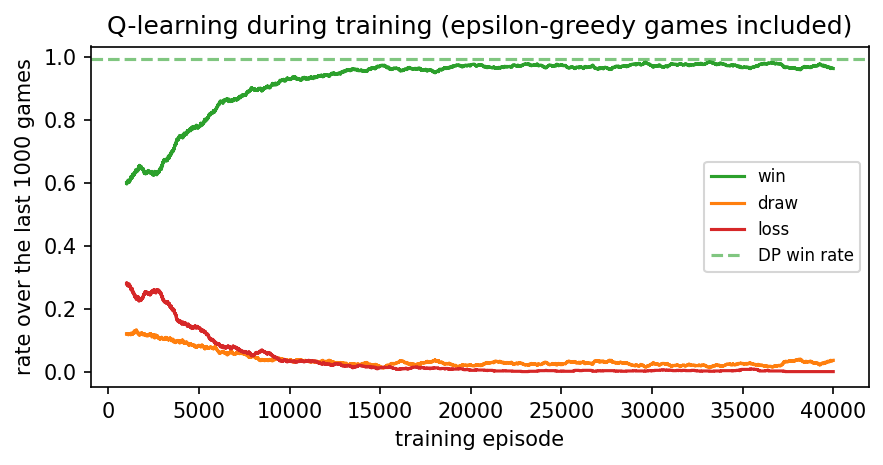

episodes      0-  5000: win 0.685  draw 0.104  loss 0.211
episodes   5000- 10000: win 0.890  draw 0.049  loss 0.061
episodes  10000- 15000: win 0.952  draw 0.026  loss 0.021
episodes  15000- 20000: win 0.965  draw 0.026  loss 0.009
episodes  20000- 25000: win 0.972  draw 0.025  loss 0.002
episodes  25000- 30000: win 0.970  draw 0.027  loss 0.003
episodes  30000- 35000: win 0.976  draw 0.021  loss 0.004
episodes  35000- 40000: win 0.971  draw 0.028  loss 0.001


In [12]:
np.random.seed(320)
EPISODES = 40000
t0 = time()
q_solver = TicTacToeQSolver(problem, alpha=0.2, gamma=gamma, epsilon=1.0, xi=0.9998)
outcomes = q_solver.train(EPISODES)
t_q = time() - t0
print(f'{EPISODES} episodes in {t_q:.1f} s, final epsilon = {q_solver.learner.epsilon:.4f}')

x, win, draw, loss = rolling_rates(outcomes, window=1000)
fig, ax = plt.subplots(1, 1, figsize=(6, 3.2), dpi=150)
ax.plot(x, win, label='win', color='#2ca02c')
ax.plot(x, draw, label='draw', color='#ff7f0e')
ax.plot(x, loss, label='loss', color='#d62728')
ax.axhline(dp_vs_random[0], color='#2ca02c', linestyle='dashed', alpha=0.6, label='DP win rate')
ax.set_xlabel('training episode')
ax.set_ylabel('rate over the last 1000 games')
ax.set_title('Q-learning during training (epsilon-greedy games included)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('figures/qlearning_training_curve.png', dpi=200)
plt.show()

for block in range(0, EPISODES, 5000):
    chunk = outcomes[block:block + 5000]
    print(f'episodes {block:6d}-{block + 5000:6d}: win {(chunk == 1).mean():.3f}  draw {(chunk == 0).mean():.3f}  loss {(chunk == -1).mean():.3f}')

## 8. Learned policy versus the DP solution

Three checks. First, greedy play of the learned Q-table against both opponents. Second, how close max_a Q(s, a) is to V*(s), split by how often the agent visited each state, because a state seen twice cannot have a settled Q value. Third, how much return the learned policy gives up, measured by evaluating the greedy Q policy exactly with the DP evaluator rather than by sampling.

In [13]:
np.random.seed(320)
q_policy = q_solver.learner.cur_policy
q_vs_random = evaluate(problem, q_policy, random_opponent, n=10000)
q_vs_minimax = evaluate(problem, q_policy, minimax_opponent, n=1000)

print(f'{"policy":<16}{"opponent":<10}{"win":>8}{"draw":>8}{"loss":>8}')
for name, res, opp in [('DP (VI)', dp_vs_random, 'random'), ('DP (VI)', dp_vs_minimax, 'minimax'),
                       ('Q-learning', q_vs_random, 'random'), ('Q-learning', q_vs_minimax, 'minimax')]:
    print(f'{name:<16}{opp:<10}{res[0]:>8.3f}{res[1]:>8.3f}{res[2]:>8.3f}')

# exact value of the greedy Q policy, evaluated with the DP machinery
q_matrix = np.zeros((problem.num_states, 9))
for s in range(problem.num_states):
    if not problem.terminal[s]:
        q_matrix[s, q_policy[s]] = 1.0
exact = TicTacToePolicyIteration(problem, gamma=gamma, init_policy=q_matrix)
exact.run_policy_evaluation(tol=1e-6)
print(f'\nexact V(empty board) under the learned policy = {exact.values[s0]:.4f}  (V* = {dp_values[s0]:.4f})')

q_max = np.array([np.max(q_solver.learner.q_table[s, problem.legal_actions[s]]) if problem.legal_actions[s] else 0.0
                  for s in range(problem.num_states)])
counts = q_solver.learner.visit_count
touched = (counts > 0) & ~problem.terminal
visited = (counts >= 50) & ~problem.terminal
print(f'non-terminal states visited at least once = {touched.sum()} of {(~problem.terminal).sum()}, at least 50 times = {visited.sum()}')
print(f'mean |max_a Q - V*| on states visited at least once = {np.abs(q_max - dp_values)[touched].mean():.4f}')
print(f'mean |max_a Q - V*| on states visited at least 50 times = {np.abs(q_max - dp_values)[visited].mean():.4f}')
print(f'|max_a Q - V*| at the empty board = {abs(q_max[s0] - dp_values[s0]):.4f}')
print(f'states where the greedy Q action has the same Q* as the DP action = '
      f'{np.mean([np.isclose(q_value(problem, dp_values, s, q_policy[s], gamma), q_value(problem, dp_values, s, dp_policy[s], gamma)) for s in np.flatnonzero(visited)]):.1%}')

policy          opponent       win    draw    loss
DP (VI)         random       0.993   0.007   0.000
DP (VI)         minimax      0.000   1.000   0.000
Q-learning      random       0.971   0.029   0.000
Q-learning      minimax      0.000   1.000   0.000



exact V(empty board) under the learned policy = 0.7617  (V* = 0.7927)
non-terminal states visited at least once = 2268 of 2423, at least 50 times = 203
mean |max_a Q - V*| on states visited at least once = 0.4802
mean |max_a Q - V*| on states visited at least 50 times = 0.1131
|max_a Q - V*| at the empty board = 0.0410
states where the greedy Q action has the same Q* as the DP action = 81.8%


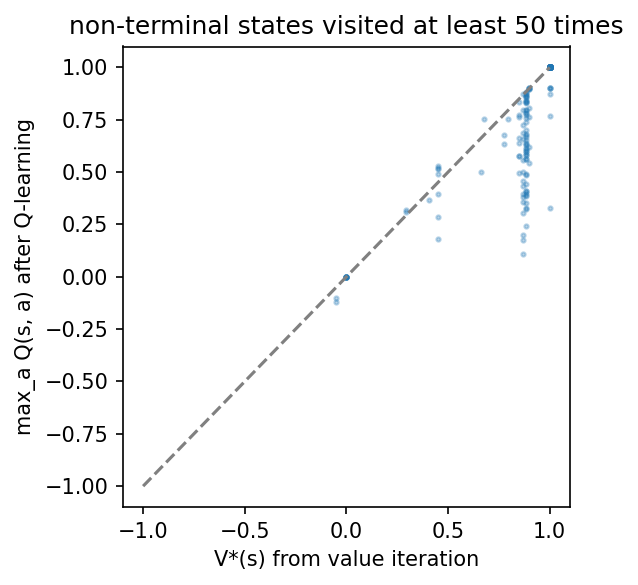

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4), dpi=150)
ax.scatter(dp_values[visited], q_max[visited], s=4, alpha=0.3)
ax.plot([-1, 1], [-1, 1], color='grey', linestyle='dashed')
ax.set_xlabel('V*(s) from value iteration')
ax.set_ylabel('max_a Q(s, a) after Q-learning')
ax.set_title('non-terminal states visited at least 50 times')
plt.tight_layout()
plt.savefig('figures/q_vs_vstar.png', dpi=200)
plt.show()

## 9. Hyper-parameter sweep

Each configuration trains for 20000 episodes from the same seed and is then evaluated greedily over 5000 games against the random opponent. The baseline is alpha 0.2, gamma 0.9, epsilon 1.0 decaying by xi 0.9998, and each row changes one thing.

In [15]:
configs = [
    ('baseline',              dict(alpha=0.2,  gamma=0.9, epsilon=1.0, xi=0.9998)),
    ('alpha 0.05',            dict(alpha=0.05, gamma=0.9, epsilon=1.0, xi=0.9998)),
    ('alpha 0.5',             dict(alpha=0.5,  gamma=0.9, epsilon=1.0, xi=0.9998)),
    ('gamma 1.0',             dict(alpha=0.2,  gamma=1.0, epsilon=1.0, xi=0.9998)),
    ('gamma 0.5',             dict(alpha=0.2,  gamma=0.5, epsilon=1.0, xi=0.9998)),
    ('fast decay xi 0.99',    dict(alpha=0.2,  gamma=0.9, epsilon=1.0, xi=0.99)),
    ('slow decay xi 0.99995', dict(alpha=0.2,  gamma=0.9, epsilon=1.0, xi=0.99995)),
    ('epsilon fixed 0.1',     dict(alpha=0.2,  gamma=0.9, epsilon=0.1, xi=1.0)),
    ('epsilon fixed 0.5',     dict(alpha=0.2,  gamma=0.9, epsilon=0.5, xi=1.0)),
]
SWEEP_EPISODES = 20000
sweep_rows, sweep_curves = [], {}
for name, kw in configs:
    np.random.seed(320)
    solver = TicTacToeQSolver(problem, **kw)
    out = solver.train(SWEEP_EPISODES)
    np.random.seed(1)
    w, d, l = evaluate(problem, solver.learner.cur_policy, random_opponent, n=5000)
    q_m = np.array([np.max(solver.learner.q_table[s, problem.legal_actions[s]]) if problem.legal_actions[s] else 0.0
                    for s in range(problem.num_states)])
    seen = (solver.learner.visit_count >= 50) & ~problem.terminal
    sweep_rows.append((name, kw['alpha'], kw['gamma'], kw['epsilon'], kw['xi'], solver.learner.epsilon,
                       (out[-2000:] == 1).mean(), w, d, l, np.abs(q_m - dp_values)[seen].mean() if kw['gamma'] == 0.9 else np.nan))
    sweep_curves[name] = rolling_rates(out, window=1000)

print(f'{"config":<24}{"alpha":>6}{"gamma":>6}{"eps0":>6}{"xi":>9}{"eps_end":>9}{"train win":>10}{"win":>7}{"draw":>7}{"loss":>7}{"|Q-V*|":>8}')
for r in sweep_rows:
    print(f'{r[0]:<24}{r[1]:>6.2f}{r[2]:>6.1f}{r[3]:>6.1f}{r[4]:>9.5f}{r[5]:>9.4f}{r[6]:>10.3f}{r[7]:>7.3f}{r[8]:>7.3f}{r[9]:>7.3f}{r[10]:>8.3f}')

config                   alpha gamma  eps0       xi  eps_end train win    win   draw   loss  |Q-V*|
baseline                  0.20   0.9   1.0  0.99980   0.0183     0.973  0.973  0.025  0.002   0.138
alpha 0.05                0.05   0.9   1.0  0.99980   0.0183     0.946  0.955  0.029  0.016   0.321
alpha 0.5                 0.50   0.9   1.0  0.99980   0.0183     0.977  0.994  0.006  0.000   0.047
gamma 1.0                 0.20   1.0   1.0  0.99980   0.0183     0.978  0.984  0.016  0.000     nan
gamma 0.5                 0.20   0.5   1.0  0.99980   0.0183     0.970  0.982  0.018  0.000     nan
fast decay xi 0.99        0.20   0.9   1.0  0.99000   0.0000     0.907  0.926  0.066  0.008   0.089
slow decay xi 0.99995     0.20   0.9   1.0  0.99995   0.3679     0.872  0.985  0.015  0.000   0.064
epsilon fixed 0.1         0.20   0.9   0.1  1.00000   0.1000     0.931  0.976  0.022  0.002   0.040
epsilon fixed 0.5         0.20   0.9   0.5  1.00000   0.5000     0.793  0.978  0.022  0.000   0.068


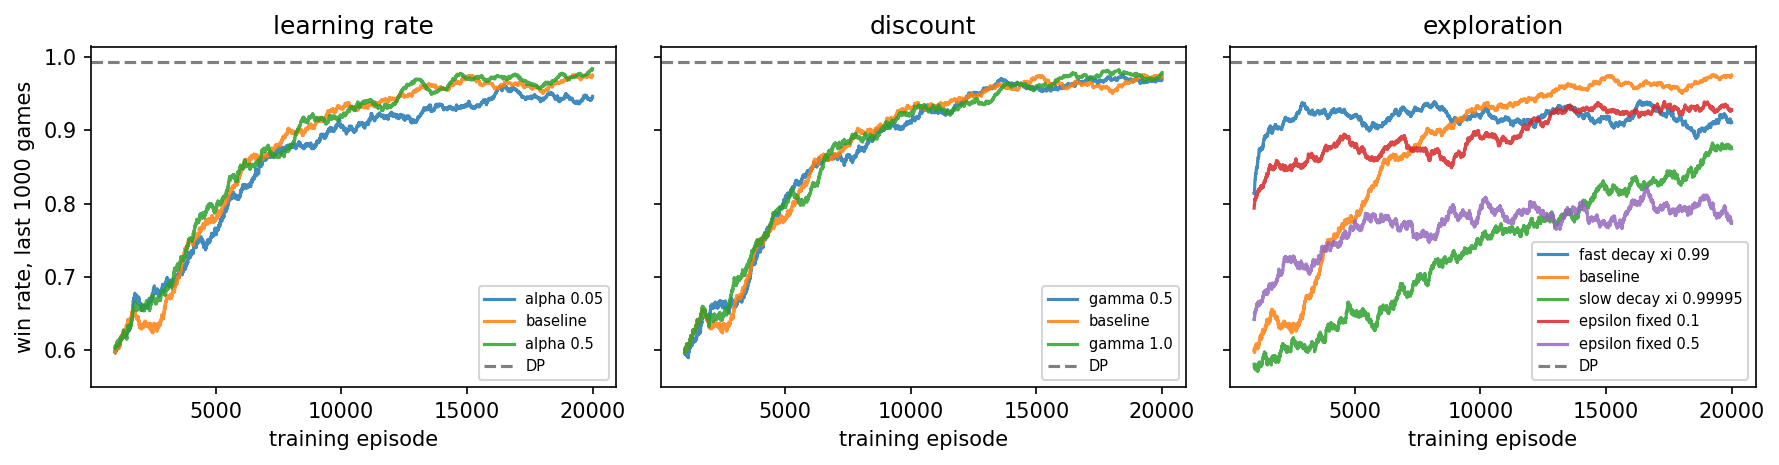

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), dpi=150, sharey='all')
groups = [('learning rate', ['alpha 0.05', 'baseline', 'alpha 0.5']),
          ('discount', ['gamma 0.5', 'baseline', 'gamma 1.0']),
          ('exploration', ['fast decay xi 0.99', 'baseline', 'slow decay xi 0.99995', 'epsilon fixed 0.1', 'epsilon fixed 0.5'])]
for ax, (title, names) in zip(axes, groups):
    for name in names:
        x, w, d, l = sweep_curves[name]
        ax.plot(x, w, label=name, alpha=0.85)
    ax.axhline(dp_vs_random[0], color='black', linestyle='dashed', alpha=0.5, label='DP')
    ax.set_title(title)
    ax.set_xlabel('training episode')
    ax.legend(fontsize=7)
axes[0].set_ylabel('win rate, last 1000 games')
plt.tight_layout()
plt.savefig('figures/hyperparameter_sweep.png', dpi=200)
plt.show()

## 10. Summary table

In [17]:
print(f'{"method":<22}{"model needed":<14}{"time (s)":>9}{"V(start)":>10}{"win vs random":>15}{"loss vs minimax":>17}')
print(f'{"policy iteration":<22}{"yes":<14}{t_pi:>9.2f}{pi_solver.values[s0]:>10.4f}{dp_vs_random[0]:>15.3f}{dp_vs_minimax[2]:>17.3f}')
print(f'{"value iteration":<22}{"yes":<14}{t_vi:>9.2f}{vi_solver.values[s0]:>10.4f}{dp_vs_random[0]:>15.3f}{dp_vs_minimax[2]:>17.3f}')
print(f'{"Q-learning (40000 ep)":<22}{"no":<14}{t_q:>9.2f}{exact.values[s0]:>10.4f}{q_vs_random[0]:>15.3f}{q_vs_minimax[2]:>17.3f}')

method                model needed   time (s)  V(start)  win vs random  loss vs minimax
policy iteration      yes                0.16    0.7927          0.993            0.000
value iteration       yes                0.17    0.7927          0.993            0.000
Q-learning (40000 ep) no                 2.54    0.7617          0.971            0.000
